# SARIMAX — teste final walk-forward

**Etapa:** avaliação final fora da amostra

Com os hiperparâmetros já congelados, o histórico se expande em cada origem e prevê somente a próxima observação real de mercado.

**Entrada:** parâmetros aprovados, 296 origens de teste e base modelável  
**Resultado principal:** 296 previsões e MAE de teste 11.5988


## 1. Importações, caminhos e funções

In [ ]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [1]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Funções de previsão do SARIMAX

In [ ]:
from itertools import product
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def ml_predict(df, origin, features, model, params):
    train = df.iloc[:origin]; origin_row = df.iloc[[origin]]
    X_train, y_train = train[features], train.TARGET
    X_origin = origin_row[features]
    if model == "PLS_Regression":
        scaler = StandardScaler().fit(X_train)
        estimator = PLSRegression(n_components=params["n_components"], scale=False)
        estimator.fit(scaler.transform(X_train), y_train)
        pred = float(estimator.predict(scaler.transform(X_origin)).ravel()[0])
    else:
        estimator = RandomForestRegressor(random_state=SEED, n_jobs=-1, **params).fit(X_train, y_train)
        pred = float(estimator.predict(X_origin)[0])
    return pred

def ts_predict(df, origin, model, params, exog):
    y = df.GOLD_PRICE.iloc[:origin+1]
    if model == "SARIMAX":
        history_exog = df[exog].iloc[: origin + 1]
        future_exog = df[exog].iloc[[origin]].copy()
        target_date = df["TARGET_DATE"].iloc[origin]
        target_day_of_week = target_date.dayofweek
        target_month = target_date.month
        future_exog.loc[:, "DOW_SIN"] = np.sin(2 * np.pi * target_day_of_week / 7)
        future_exog.loc[:, "DOW_COS"] = np.cos(2 * np.pi * target_day_of_week / 7)
        future_exog.loc[:, "MONTH_SIN"] = np.sin(2 * np.pi * target_month / 12)
        future_exog.loc[:, "MONTH_COS"] = np.cos(2 * np.pi * target_month / 12)
        fitted = SARIMAX(y, exog=history_exog, order=tuple(params["order"]), seasonal_order=tuple(params["seasonal_order"]), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        return float(fitted.get_forecast(steps=1, exog=future_exog).predicted_mean.iloc[0])
    fitted = ExponentialSmoothing(y, trend=params["trend"], damped_trend=params["damped_trend"], seasonal=params["seasonal"], seasonal_periods=params["seasonal_periods"], initialization_method="estimated").fit(optimized=True)
    return float(fitted.forecast(1).iloc[0])



In [2]:
def predict_one(df, origin, model, params, protocol):
    if model in {"Random_Forest", "PLS_Regression"}: return ml_predict(df, origin, protocol["decisions"]["features"], model, params)
    return ts_predict(df, origin, model, params, protocol["sarimax_exog"])

def evaluate(df, ids, model, params, protocol):
    started=time.perf_counter(); records=[]
    for origin in ids:
        assert (df["TARGET_DATE"].iloc[:origin] <= df["DATE"].iloc[origin]).all()
        origin_started = time.perf_counter()
        prediction = predict_one(df, origin, model, params, protocol)
        origin_elapsed = time.perf_counter() - origin_started
        actual = float(df.TARGET.iloc[origin])
        records.append({"dataset":"gold", "model":model, "forecast_origin":df.DATE.iloc[origin].date().isoformat(), "target_date":df.TARGET_DATE.iloc[origin].date().isoformat(), "horizon":1, "y_true":actual, "y_pred":prediction, "residual":actual-prediction, "elapsed_seconds":origin_elapsed})
    output=pd.DataFrame(records); assert np.isfinite(output[["y_true","y_pred","residual"]]).all().all(); assert np.allclose(output.residual, output.y_true-output.y_pred)
    return output, float(mean_absolute_error(output.y_true, output.y_pred)), time.perf_counter()-started


## 3. Protocolo walk-forward

A janela é expansiva. Em cada origem, usamos somente o histórico disponível para prever a próxima observação de mercado.

período,treino inicial,primeira origem,última origem,primeira data-alvo,última data-alvo,origens,passo,horizonte,janela
validation,6904,2000-06-27,2007-05-21,2000-06-28,2007-05-22,296,5,1,expansiva
test,6904,2007-06-06,2014-04-03,2007-06-07,2014-04-04,296,5,1,expansiva


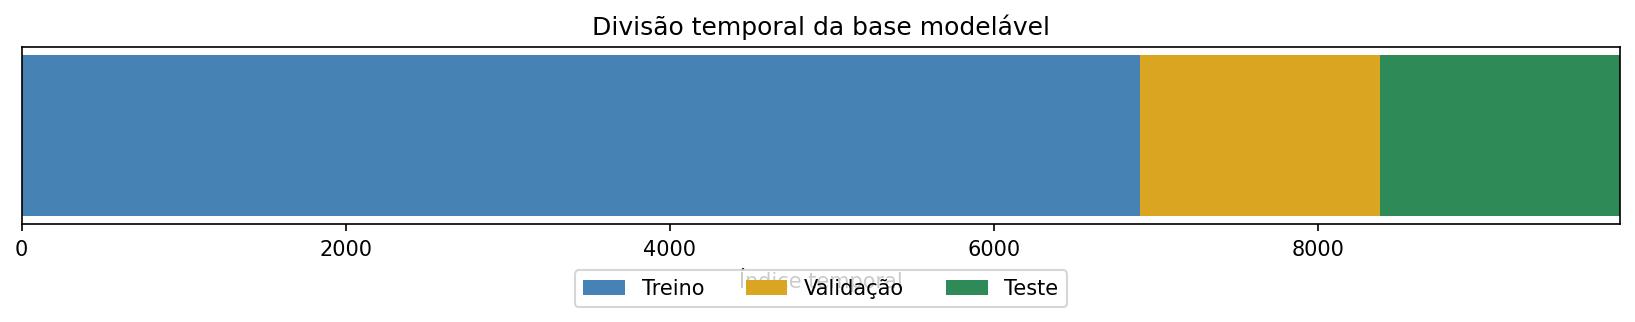

In [ ]:
# Resumo do protocolo congelado
protocol = load_protocol(require_data_decisions=True)
origin_audit = pd.read_csv(OUT / "origin_audit.csv")
protocol_table = origin_audit[[
    "split", "first_origin_date", "last_origin_date",
    "first_target_date", "last_target_date", "n_origins", "minimum_step",
]].copy()
protocol_table.insert(1, "treino inicial", protocol["splits"]["train_end"])
protocol_table["horizonte"] = protocol["horizon_observations"]
protocol_table["janela"] = "expansiva"
display(protocol_table)

fig, ax = plt.subplots(figsize=(11, 2.4))
train_end = protocol["splits"]["train_end"]
validation_end = protocol["splits"]["validation_end"]
n_rows = protocol["splits"]["n_rows"]
ax.barh([0], [train_end], left=[0], color="steelblue", label="Treino")
ax.barh([0], [validation_end - train_end], left=[train_end], color="goldenrod", label="Validação")
ax.barh([0], [n_rows - validation_end], left=[validation_end], color="seagreen", label="Teste")
ax.set(title="Divisão temporal da base modelável", xlabel="Índice temporal")
ax.set_yticks([])
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2))
plt.tight_layout()
plt.show()

## 4. Execução original do teste final

> **Execução pesada**
>
> Esta célula produziu originalmente os resultados congelados. Ela é mantida para documentar o processo e não deve ser reexecutada apenas para visualizar o notebook.

In [ ]:
MODEL="SARIMAX"
df=load_data(); protocol=load_protocol(require_data_decisions=True)
if protocol["execution_phase"] != "final_test_authorized" or protocol["test_gate"]["status"] != "authorized": raise RuntimeError("DECISÃO NECESSÁRIA: o teste final ainda não foi autorizado.")
if MODEL not in protocol["decisions"]["accepted_parameters"]: raise RuntimeError("DECISÃO NECESSÁRIA: aceite os parâmetros vencedores antes do teste final.")
params=protocol["decisions"]["accepted_parameters"][MODEL]
test_origins = origins(protocol, "test")
manifest = pd.read_csv(OUT / "origin_manifest.csv")
expected = manifest[manifest.split == "test"].reset_index(drop=True)
assert expected.origin_index.tolist() == test_origins
predictions, mae, elapsed=evaluate(df, test_origins, MODEL, params, protocol)
assert predictions.forecast_origin.tolist() == expected.forecast_origin.tolist()
assert predictions.target_date.tolist() == expected.target_date.tolist()
path=OUT / "predictions.csv"; old=pd.read_csv(path) if path.exists() else pd.DataFrame(columns=predictions.columns)
combined=pd.concat([old[old.model != MODEL],predictions],ignore_index=True); combined.to_csv(path,index=False)
metric=pd.DataFrame([{"dataset":"gold","model":MODEL,"split":"test_final","n_forecasts":len(predictions),"mae":mae,"elapsed_seconds":elapsed}])
mpath=OUT / "metrics.csv"; previous=pd.read_csv(mpath) if mpath.exists() else pd.DataFrame(columns=metric.columns)
pd.concat([previous[previous.model != MODEL],metric],ignore_index=True).to_csv(mpath,index=False)
origin = protocol["splits"]["validation_end"]
fitted = SARIMAX(df.GOLD_PRICE.iloc[:origin+1], exog=df[protocol["sarimax_exog"]].iloc[:origin+1], order=tuple(params["order"]), seasonal_order=tuple(params["seasonal_order"]), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
coefficients = pd.DataFrame({"dataset": "gold", "model": MODEL, "feature": fitted.params.index, "coefficient": fitted.params.values, "p_value": fitted.pvalues.values, "split": "first_test_origin"})
coefficients.to_csv(OUT / "sarimax_coefficients.csv", index=False)
display(metric); print("Previsões e coeficientes finais salvos; execute o notebook de resíduos.")

## Resultado congelado

In [ ]:
# Leitura leve dos resultados congelados — não repete o walk-forward
metricas_congeladas = pd.read_csv(OUT / "metrics.csv")
previsoes_congeladas = pd.read_csv(OUT / "predictions.csv")

display(metricas_congeladas.loc[metricas_congeladas["model"] == "SARIMAX"])
display(previsoes_congeladas.loc[previsoes_congeladas["model"] == "SARIMAX"].head())

model,n_forecasts,mae,elapsed_seconds,rank_gold
SARIMAX,296,11.598841,3232.069655,2


forecast_origin,target_date,y_true,y_pred,residual
2007-06-06,2007-06-07,670.85,670.025480,0.824520
2007-06-13,2007-06-14,650.75,644.458585,6.291415
2007-06-20,2007-06-21,654.50,659.566393,-5.066393
2007-06-28,2007-06-29,648.50,645.163216,3.336784
2007-07-05,2007-07-06,647.75,655.879672,-8.129672


### Real x Previsto

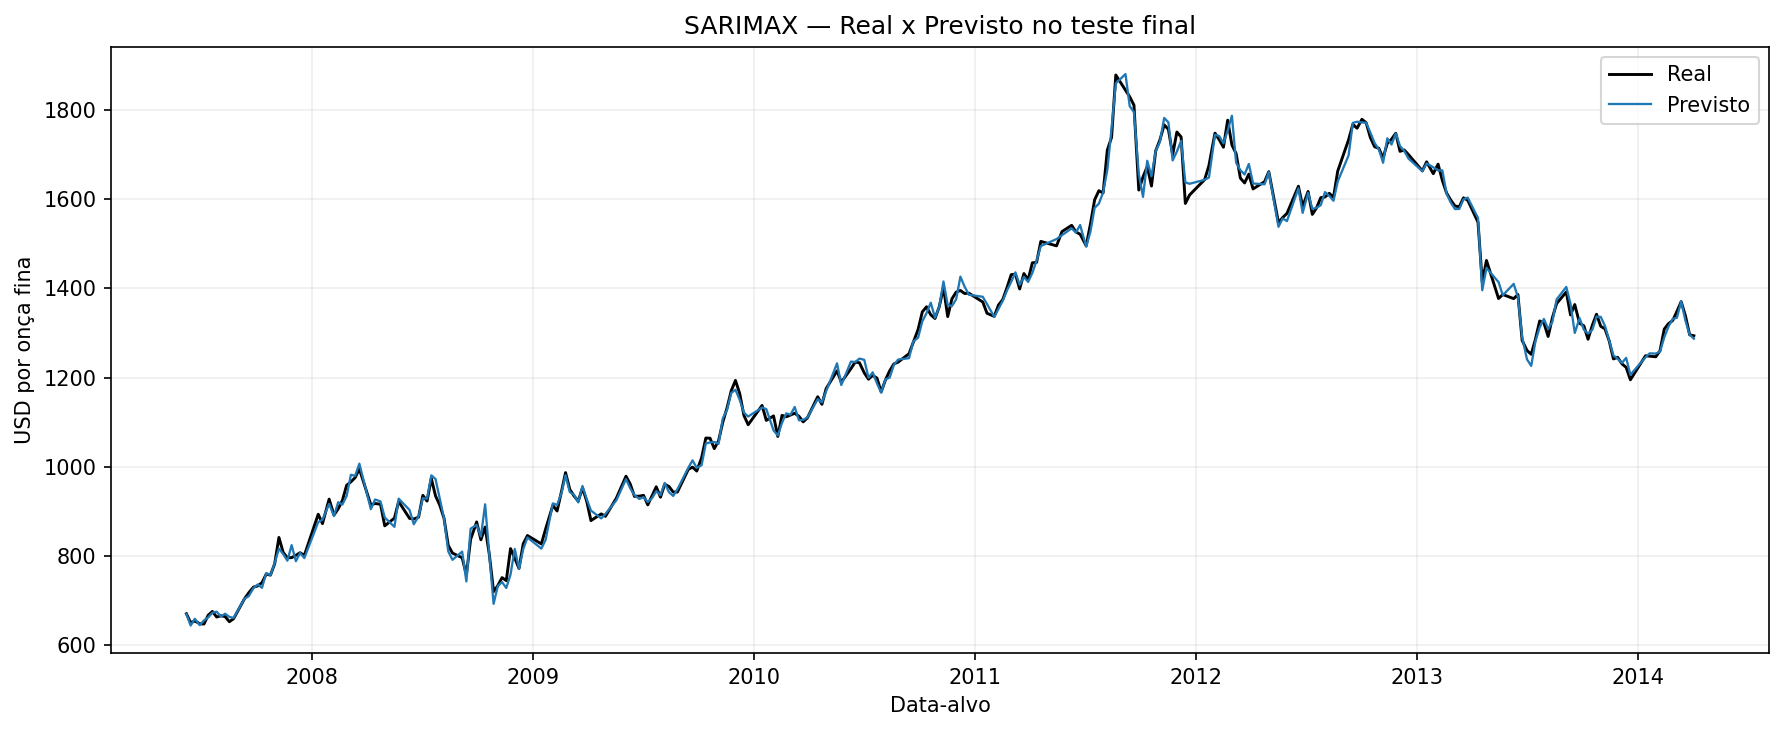

In [ ]:
# Gráfico das previsões congeladas
predictions_frozen = pd.read_csv(OUT / "predictions.csv", parse_dates=["target_date"])
model_predictions = predictions_frozen[predictions_frozen["model"] == "SARIMAX"].sort_values("target_date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(model_predictions["target_date"], model_predictions["y_true"], label="Real", color="black", linewidth=1.4)
ax.plot(model_predictions["target_date"], model_predictions["y_pred"], label="Previsto", color="tab:blue", linewidth=1.1)
ax.set(title="SARIMAX — Real x Previsto no teste final", xlabel="Data-alvo", ylabel="USD por onça fina")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

O SARIMAX possui 296 previsões nas origens comuns. O MAE exibido é o resultado final congelado.

## Interpretação

Todos os modelos usam as mesmas origens, horizonte e valores reais. Esta célula é mantida para documentar a obtenção do resultado, mas o teste final já foi concluído e não deve ser repetido.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/predictions.csv`
- `outputs/metrics.csv`
- `outputs/hyperparameters.csv`
- `outputs/graficos/test_real_vs_pred_sarimax.png`
- `outputs/graficos/walkforward_split_timeline.png`